# Three-Factor Nelson–Siegel IRRBB Engine

## Purpose

This notebook is an auditable **IRRBB internal-measurement-system prototype**. It is designed to demonstrate model architecture, risk measurement and model governance; it is not represented as a production regulatory calculation.

The notebook connects:

1. Official Federal Reserve `SVENY` continuously compounded zero-coupon yields when network access is available, with an explicitly labelled offline demonstration panel for reproducibility.
2. A train/validation/test curve representation with no look-ahead in decay calibration.
3. Numerical identification, PCA factor-alignment, out-of-sample and curve-shape diagnostics.
4. Basel-segmented NMDs with core caps and average-maturity controls.
5. A reconciled banking book, distinct accounting equity and Tier 1 capital, and an off-balance-sheet interest-rate swap.
6. Basel-prescribed six-scenario ΔEVE, a 15% Tier 1 outlier diagnostic and 12-month constant-balance-sheet ΔNII.
7. Behavioural-assumption sensitivity, validation assertions and versioned machine-readable artifacts.

### Important boundary

The Fed series are already smoothed zero-coupon estimates. This notebook performs **parametric representation and model-risk analysis**, not primary-market bond bootstrapping. In a bank, an approved curve service, behavioural model inventory and independent validation process would sit upstream of this engine.

### Primary references

- [Basel Framework SRP31 — IRRBB](https://www.bis.org/basel_framework/chapter/SRP/31.htm?inforce=20260101&published=20240716)
- [BCBS d578 — recalibrated shocks effective 1 January 2026](https://www.bis.org/bcbs/publ/d578.htm)
- [Basel Framework DIS70 — IRRBB disclosure](https://www.bis.org/basel_framework/chapter/DIS/70.htm)
- [Federal Reserve Gürkaynak–Sack–Wright nominal yield curve](https://www.federalreserve.gov/data/nominal-yield-curve.htm)

## 1. Configuration, controls and data contracts

Units are explicit: curve observations are percentage points, shocks are basis points, and monetary amounts are millions. The delivered outputs were produced in an offline execution environment; the source code defaults to `AUTO` and pulls the official Fed series when available.

In [1]:
from __future__ import annotations

import io
import json
import hashlib
import os
import warnings
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy.optimize import linear_sum_assignment, minimize
from sklearn.decomposition import PCA
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.random.seed(42)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 115,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
FIGURE_DIR = ARTIFACT_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

@dataclass(frozen=True)
class ProjectConfig:
    currency: str = "USD"
    lookback_years: int = 4
    train_fraction: float = 0.60
    validation_fraction: float = 0.20
    tier1_capital_mm: float = 170.0
    accounting_equity_mm: float = 200.0
    outlier_limit: float = 0.15
    shock_decay_years: float = 4.0
    post_shock_floor_pct: float | None = None
    nii_horizon_months: int = 12
    data_mode: str = os.getenv("IRRBB_DATA_MODE", "AUTO").upper()

CFG = ProjectConfig()
ZERO_TENORS = np.array([1, 2, 3, 5, 7, 10, 15, 20, 30], dtype=float)
ZERO_LABELS = [f"{int(t)}Y" for t in ZERO_TENORS]
ZERO_COLUMNS = [f"SVENY{int(t):02d}" for t in ZERO_TENORS]
FED_ZERO_CURVE_CSV = "https://www.federalreserve.gov/data/yield-curve-tables/feds200628.csv"

# BCBS shock table effective 1 January 2026 (basis points).
SHOCK_CONFIG_BP = {
    "USD": {"parallel": 200.0, "short": 300.0, "long": 225.0},
    "TRY": {"parallel": 400.0, "short": 500.0, "long": 300.0},
}
if CFG.currency not in SHOCK_CONFIG_BP:
    raise ValueError(f"Unsupported shock currency: {CFG.currency}")

## 2. Market-data acquisition and temporal split

The loader treats data provenance as a first-class output. Decay parameters are calibrated on the training sample, selected using validation error and then frozen before the untouched test sample is evaluated.

In [2]:
def load_fed_gsw_zero_curve(url=FED_ZERO_CURVE_CSV, lookback_years=CFG.lookback_years):
    """Load official continuously compounded SVENY zero-coupon yields."""
    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0",
        "Accept": "text/csv,text/plain,*/*",
        "Referer": "https://www.federalreserve.gov/data/nominal-yield-curve.htm",
    })
    response = session.get(url, timeout=30)
    response.raise_for_status()
    lines = response.content.decode("utf-8-sig").splitlines()
    header_idx = next(i for i, line in enumerate(lines) if line.startswith("Date,"))
    raw = pd.read_csv(io.StringIO("\n".join(lines[header_idx:])))
    raw["Date"] = pd.to_datetime(raw["Date"], errors="coerce")
    missing = sorted(set(ZERO_COLUMNS) - set(raw.columns))
    if missing:
        raise KeyError(f"Missing official SVENY columns: {missing}")
    panel = (
        raw.set_index("Date")[ZERO_COLUMNS]
        .apply(pd.to_numeric, errors="coerce")
        .replace(-999.99, np.nan)
    )
    panel.columns = ZERO_LABELS
    cutoff = panel.index.max() - pd.DateOffset(years=lookback_years)
    panel = panel.loc[panel.index >= cutoff].sort_index().dropna(how="all")
    panel = panel.interpolate(limit=3, limit_direction="both").dropna()
    if len(panel) < 400:
        raise ValueError(f"Curve panel too short after cleaning: {len(panel)} rows")
    return panel


def load_zero_curve_panel():
    offline_path = DATA_DIR / "offline_reference_zero_curve.csv"
    if CFG.data_mode == "OFFLINE":
        panel = pd.read_csv(offline_path, index_col="Date", parse_dates=True)
        return panel[ZERO_LABELS], "OFFLINE synthetic reference panel — not market data"
    try:
        panel = load_fed_gsw_zero_curve()
        panel.to_csv(DATA_DIR / "latest_fed_gsw_zero_curve.csv")
        return panel, "Federal Reserve GSW SVENY zero-coupon curve (live)"
    except Exception as exc:
        if CFG.data_mode == "LIVE":
            raise
        panel = pd.read_csv(offline_path, index_col="Date", parse_dates=True)
        note = f"OFFLINE synthetic reference panel — live pull failed: {type(exc).__name__}"
        return panel[ZERO_LABELS], note


zero_yields, DATA_SOURCE = load_zero_curve_panel()
zero_yields = zero_yields.sort_index().astype(float)

n_obs = len(zero_yields)
train_end = int(n_obs * CFG.train_fraction)
validation_end = int(n_obs * (CFG.train_fraction + CFG.validation_fraction))
if not (200 <= train_end < validation_end < n_obs):
    raise ValueError("Invalid train/validation/test split")

train_panel = zero_yields.iloc[:train_end]
validation_panel = zero_yields.iloc[train_end:validation_end]
test_panel = zero_yields.iloc[validation_end:]

print(f"Data source       : {DATA_SOURCE}")
print(f"Observations      : {n_obs:,}")
print(f"Date range        : {zero_yields.index.min().date()} -> {zero_yields.index.max().date()}")
print(f"Train / val / test: {len(train_panel)} / {len(validation_panel)} / {len(test_panel)}")
display(zero_yields.tail())

Data source       : Federal Reserve GSW SVENY zero-coupon curve (live)
Observations      : 1,000
Date range        : 2022-07-18 -> 2026-07-17
Train / val / test: 600 / 200 / 200


,1Y,2Y,3Y,5Y,7Y,10Y,15Y,20Y,30Y
Date,,,,,,,,,
2026-07-13,4.1505,4.1898,4.2387,4.3559,4.4877,4.6894,4.9831,5.1821,5.2740
2026-07-14,4.0700,4.1164,4.1716,4.3001,4.4411,4.6538,4.9595,5.1651,5.2616
2026-07-15,4.0208,4.0640,4.1179,4.2480,4.3944,4.6181,4.9424,5.1606,5.2620
2026-07-16,4.0429,4.0871,4.1416,4.2718,4.4173,4.6391,4.9601,5.1763,5.2781
2026-07-17,4.0611,4.1005,4.1503,4.2716,4.4091,4.6212,4.9323,5.1455,5.2541


## 3. Three-factor Nelson–Siegel representation

The representation is

$$z(\tau)=\beta_0+\beta_1L_1(\tau;\lambda_1)+\beta_2L_2(\tau;\lambda_1).$$

This notebook uses **three beta factors and one decay hyperparameter**. The decay parameter is calibrated only on the training sample and selected using validation error. Daily beta coefficients are fitted linearly with the decay fixed. This creates a parsimonious structural factor model whose level, slope and curvature interpretation can be benchmarked against out-of-sample PCA factors.

In [3]:
def fit_panel(panel_values, design):
    betas = np.linalg.lstsq(design, panel_values.T, rcond=None)[0].T
    fitted = betas @ design.T
    return betas, fitted


def rmse_by_date_bp(actual, fitted):
    return np.sqrt(np.mean((fitted - actual) ** 2, axis=1)) * 100.0


def variance_inflation_factors(design):
    values = {}
    for j in range(design.shape[1]):
        y = design[:, j]
        X = np.delete(design, j, axis=1)
        coef = np.linalg.lstsq(X, y, rcond=None)[0]
        residual = y - X @ coef
        sse = float(residual @ residual)
        sst = float(((y - y.mean()) ** 2).sum())
        r2 = 1.0 - sse / sst if sst > 1e-12 else 0.0
        values[f"loading_{j}"] = 1.0 / max(1.0 - r2, 1e-12)
    return values


def max_off_diagonal_abs_corr(matrix):
    corr = np.corrcoef(matrix.T)
    mask = ~np.eye(corr.shape[0], dtype=bool)
    return float(np.max(np.abs(corr[mask])))


def build_factor_alignment(params, beta_columns):
    train_changes = train_panel.diff().dropna()
    test_changes = test_panel.diff().dropna()
    pca = PCA(n_components=3).fit(train_changes.values)
    test_scores = pca.transform(test_changes.values)
    beta_changes = params[beta_columns].diff().reindex(test_changes.index).dropna()
    common = beta_changes.index.intersection(test_changes.index)
    scores = pd.DataFrame(
        pca.transform(test_changes.loc[common].values),
        index=common,
        columns=["PC1", "PC2", "PC3"],
    )
    beta_delta = beta_changes.loc[common]
    corr = pd.DataFrame(index=scores.columns, columns=beta_columns, dtype=float)
    for pc in scores.columns:
        for beta in beta_columns:
            corr.loc[pc, beta] = np.corrcoef(scores[pc], beta_delta[beta])[0, 1]
    row_idx, col_idx = linear_sum_assignment(-np.abs(corr.values))
    matched = [abs(float(corr.values[r, c])) for r, c in zip(row_idx, col_idx)]
    return pca, corr, matched


def curve_shape_checks(params, beta_columns, rate_function):
    grid = np.linspace(0.05, 30.0, 600)
    sample_dates = list(params.index[-min(40, len(params)):])
    monotonicity_violations = 0
    min_forward, max_forward = np.inf, -np.inf
    for date in sample_dates:
        beta = params.loc[date, beta_columns].values
        z_pct = rate_function(beta, grid)
        discount = np.exp(-(z_pct / 100.0) * grid)
        monotonicity_violations += int(np.any(np.diff(discount) > 1e-10))
        dz_dt = np.gradient(z_pct / 100.0, grid)
        forward = z_pct / 100.0 + grid * dz_dt
        min_forward = min(min_forward, float(np.min(forward)))
        max_forward = max(max_forward, float(np.max(forward)))
    return {
        "sampled_curve_dates": len(sample_dates),
        "discount_monotonicity_violations": monotonicity_violations,
        "minimum_instantaneous_forward_pct": 100.0 * min_forward,
        "maximum_instantaneous_forward_pct": 100.0 * max_forward,
    }

In [4]:
MODEL_KEY = "ns3"
MODEL_NAME = "Three-factor Nelson–Siegel"
BETA_COLUMNS = ["beta0", "beta1", "beta2"]


def model_loadings(tau, lambda1):
    tau = np.asarray(tau, dtype=float)
    x = np.maximum(tau, 1e-8) / lambda1
    slope = -np.expm1(-x) / x
    curvature = slope - np.exp(-x)
    return np.column_stack([np.ones_like(tau), slope, curvature])


def calibrate_lambda():
    train_values = train_panel.iloc[::3].values
    candidates = []
    bounds = [(np.log(0.10), np.log(10.0))]

    def objective(x):
        lambda1 = np.exp(x[0])
        design = model_loadings(ZERO_TENORS, lambda1)
        _, fitted = fit_panel(train_values, design)
        return np.mean((fitted - train_values) ** 2)

    for start in [0.5, 1.0, 1.5, 2.5, 4.0, 6.0]:
        result = minimize(objective, np.log([start]), method="L-BFGS-B", bounds=bounds)
        if not (result.success and np.isfinite(result.fun)):
            continue
        lambda1 = float(np.exp(result.x[0]))
        design = model_loadings(ZERO_TENORS, lambda1)
        _, fitted_val = fit_panel(validation_panel.values, design)
        validation_rmse = float(rmse_by_date_bp(validation_panel.values, fitted_val).mean())
        candidates.append((validation_rmse, result.fun, lambda1, result))
    if not candidates:
        raise RuntimeError("Nelson–Siegel calibration failed")
    return min(candidates, key=lambda x: (x[0], x[1]))


validation_score, _, lambda1_hat, optimizer_result = calibrate_lambda()
lambda2_hat = None
design = model_loadings(ZERO_TENORS, lambda1_hat)

Model                     : Three-factor Nelson–Siegel
Global lambda1            : 2.6154 years
Design condition number   : 17.1
Max loading correlation   : 0.3752
Train mean RMSE           : 4.100 bp
Validation mean RMSE      : 3.526 bp
Test mean RMSE            : 3.387 bp
Test 95th percentile RMSE : 5.501 bp


,beta0,beta1,beta2,lambda1
Date,,,,
2026-07-13,5.592399,-1.295297,-2.238794,2.615395
2026-07-14,5.593796,-1.382474,-2.299962,2.615395
2026-07-15,5.614264,-1.432957,-2.469537,2.615395
2026-07-16,5.626380,-1.426482,-2.440506,2.615395
2026-07-17,5.587501,-1.360626,-2.415506,2.615395


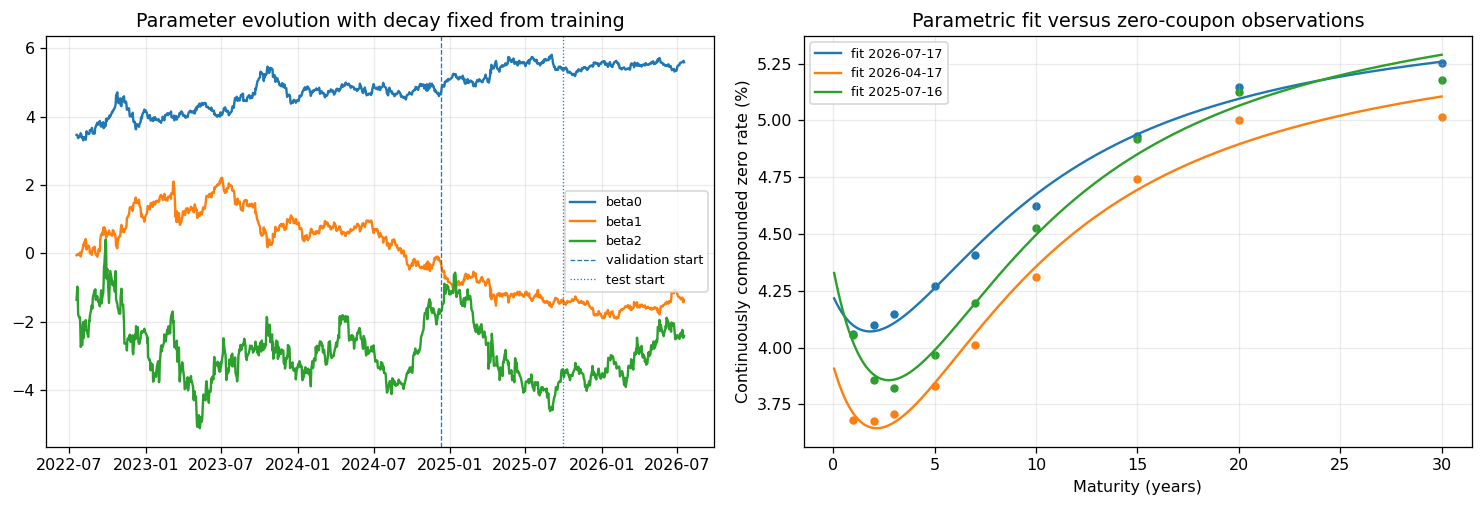

In [5]:
def zero_rate_pct(beta, tau):
    return model_loadings(np.atleast_1d(tau), lambda1_hat) @ np.asarray(beta, dtype=float)

all_betas, fitted_values = fit_panel(zero_yields.values, design)
params = pd.DataFrame(all_betas, index=zero_yields.index, columns=BETA_COLUMNS)
params["lambda1"] = lambda1_hat
if lambda2_hat is not None:
    params["lambda2"] = lambda2_hat

current_beta = params.iloc[-1][BETA_COLUMNS].values
def fitted_zero_rate_pct(tau):
    return zero_rate_pct(current_beta, tau)

errors_bp = (fitted_values - zero_yields.values) * 100.0
train_rmse = rmse_by_date_bp(zero_yields.iloc[:train_end].values, fitted_values[:train_end])
validation_rmse = rmse_by_date_bp(zero_yields.iloc[train_end:validation_end].values, fitted_values[train_end:validation_end])
test_rmse = rmse_by_date_bp(zero_yields.iloc[validation_end:].values, fitted_values[validation_end:])
test_errors_bp = errors_bp[validation_end:]
design_condition = float(np.linalg.cond(design))
max_loading_corr = max_off_diagonal_abs_corr(design[:, 1:])
vif = variance_inflation_factors(design)

fit_diagnostics = pd.DataFrame({
    "date": zero_yields.index,
    "sample": np.where(np.arange(n_obs) < train_end, "train", np.where(np.arange(n_obs) < validation_end, "validation", "test")),
    "rmse_bp": rmse_by_date_bp(zero_yields.values, fitted_values),
    "max_abs_error_bp": np.max(np.abs(errors_bp), axis=1),
}).set_index("date")

print(f"Model                     : {MODEL_NAME}")
print(f"Global lambda1            : {lambda1_hat:.4f} years")
if lambda2_hat is not None:
    print(f"Global lambda2            : {lambda2_hat:.4f} years")
print(f"Design condition number   : {design_condition:,.1f}")
print(f"Max loading correlation   : {max_loading_corr:.4f}")
print(f"Train mean RMSE           : {train_rmse.mean():.3f} bp")
print(f"Validation mean RMSE      : {validation_rmse.mean():.3f} bp")
print(f"Test mean RMSE            : {test_rmse.mean():.3f} bp")
print(f"Test 95th percentile RMSE : {np.quantile(test_rmse, 0.95):.3f} bp")
display(params.tail())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for beta in BETA_COLUMNS:
    axes[0].plot(params.index, params[beta], label=beta)
axes[0].axvline(zero_yields.index[train_end], linestyle="--", linewidth=0.8, label="validation start")
axes[0].axvline(zero_yields.index[validation_end], linestyle=":", linewidth=0.8, label="test start")
axes[0].set_title("Parameter evolution with decay fixed from training")
axes[0].legend(fontsize=8)

fine_tau = np.linspace(0.05, 30.0, 500)
for pos in [-1, -63, -252]:
    if abs(pos) <= len(zero_yields):
        date = zero_yields.index[pos]
        beta = params.loc[date, BETA_COLUMNS].values
        axes[1].plot(fine_tau, zero_rate_pct(beta, fine_tau), label=f"fit {date.date()}")
        axes[1].scatter(ZERO_TENORS, zero_yields.loc[date], s=18)
axes[1].set_title("Parametric fit versus zero-coupon observations")
axes[1].set_xlabel("Maturity (years)")
axes[1].set_ylabel("Continuously compounded zero rate (%)")
axes[1].legend(fontsize=8)
plt.tight_layout()
CURVE_FIGURE = FIGURE_DIR / f"{MODEL_KEY}_01_curve_fit.png"
plt.savefig(CURVE_FIGURE, bbox_inches="tight")
plt.show()

## 4. Identification, factor alignment and out-of-sample diagnostics

Low curve RMSE is not sufficient evidence of a sound factor model. The diagnostics below measure loading-matrix conditioning, pairwise loading correlation, variance inflation, out-of-sample error and correspondence with PCA factors estimated only from training-period changes. PCA signs are arbitrary, so the decision statistics use absolute correlations.

Training PCA explained variance: [0.8293 0.1201 0.0288]
PC1–Δbeta0 absolute correlation: 0.579
Mean matched factor correlation : 0.614


,VIF
loading_0,1.000000
loading_1,1.163837
loading_2,1.163837


,beta0,beta1,beta2
PC1,0.578891,-0.237481,0.786743
PC2,0.854023,-0.977088,-0.324450
PC3,0.000509,0.202468,-0.037987


,value
sampled_curve_dates,40.000000
discount_monotonicity_violations,0.000000
minimum_instantaneous_forward_pct,3.865802
maximum_instantaneous_forward_pct,5.674225


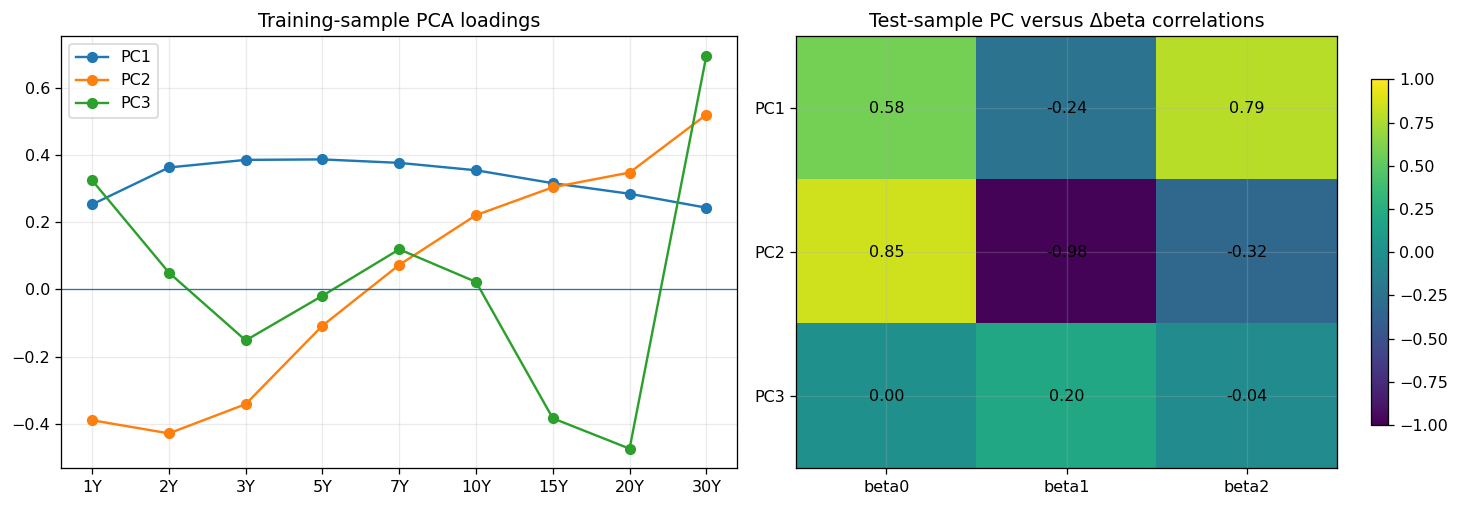

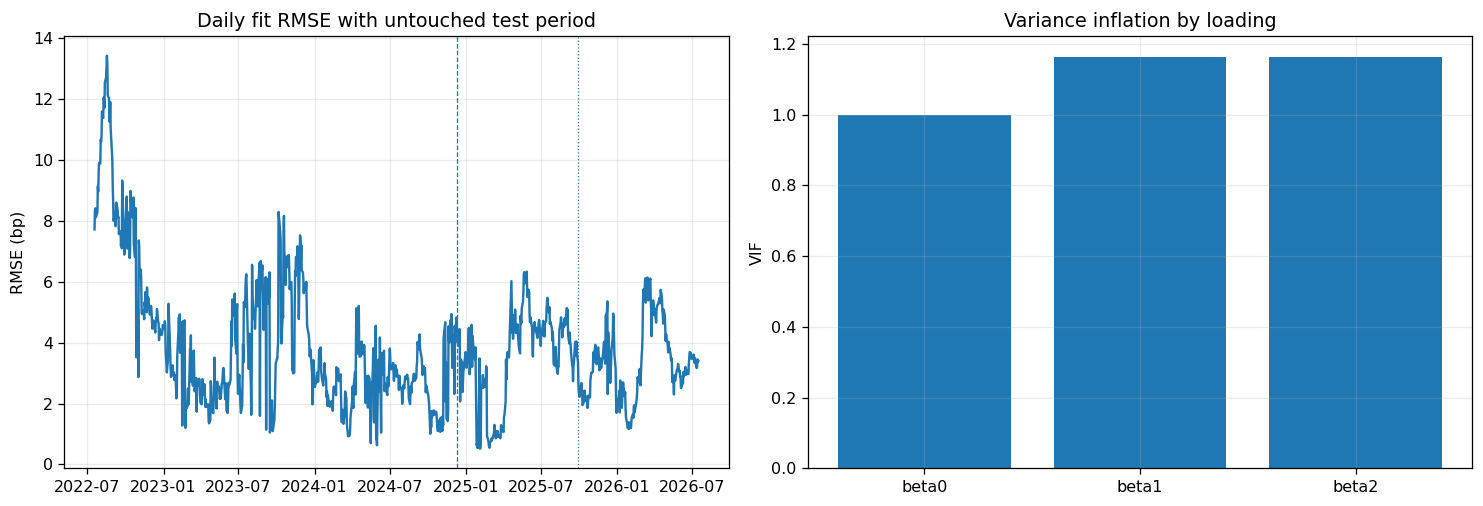

In [6]:
pca, factor_corr, matched_factor_corr = build_factor_alignment(params, BETA_COLUMNS)
curve_checks = curve_shape_checks(params, BETA_COLUMNS, zero_rate_pct)

print("Training PCA explained variance:", np.round(pca.explained_variance_ratio_, 4))
print(f"PC1–Δbeta0 absolute correlation: {abs(factor_corr.loc['PC1', 'beta0']):.3f}")
print(f"Mean matched factor correlation : {np.mean(matched_factor_corr):.3f}")
display(pd.DataFrame({"VIF": vif}))
display(factor_corr)
display(pd.Series(curve_checks).to_frame("value"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, pc in enumerate(["PC1", "PC2", "PC3"]):
    axes[0].plot(ZERO_LABELS, pca.components_[i], marker="o", label=pc)
axes[0].axhline(0.0, linewidth=0.8)
axes[0].set_title("Training-sample PCA loadings")
axes[0].legend()
image = axes[1].imshow(factor_corr.astype(float).values, aspect="auto", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(BETA_COLUMNS)), BETA_COLUMNS)
axes[1].set_yticks(range(3), ["PC1", "PC2", "PC3"])
axes[1].set_title("Test-sample PC versus Δbeta correlations")
for i in range(3):
    for j in range(len(BETA_COLUMNS)):
        axes[1].text(j, i, f"{factor_corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(image, ax=axes[1], shrink=0.8)
plt.tight_layout()
FACTOR_FIGURE = FIGURE_DIR / f"{MODEL_KEY}_02_factor_alignment.png"
plt.savefig(FACTOR_FIGURE, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fit_diagnostics.index, fit_diagnostics.rmse_bp)
axes[0].axvline(zero_yields.index[train_end], linestyle="--", linewidth=0.8)
axes[0].axvline(zero_yields.index[validation_end], linestyle=":", linewidth=0.8)
axes[0].set_title("Daily fit RMSE with untouched test period")
axes[0].set_ylabel("RMSE (bp)")
axes[1].bar(range(design.shape[1]), [vif[f"loading_{j}"] for j in range(design.shape[1])])
axes[1].set_xticks(range(design.shape[1]), BETA_COLUMNS)
axes[1].set_title("Variance inflation by loading")
axes[1].set_ylabel("VIF")
plt.tight_layout()
IDENT_FIGURE = FIGURE_DIR / f"{MODEL_KEY}_03_identification.png"
plt.savefig(IDENT_FIGURE, bbox_inches="tight")
plt.show()

## 5. Behavioural NMD segmentation and replicating portfolio

Basel requires NMD segmentation and imposes caps on core proportions and average repricing maturities. The illustrative calibration separates volume stability from rate stickiness and applies the Table 4 limits: 90%/5 years for retail transactional, 70%/4.5 years for retail non-transactional and 50%/4 years for wholesale. This remains a transparent demonstration because no account-level deposit data are supplied.

,segment,current_mm,stable_volume_mm,estimated_core_mm,governance_cap_mm,core_mm,noncore_mm,core_ratio,weighted_core_maturity_y,maturity_cap_y,beta_up,beta_down,repricing_lag_months
0,Retail transactional,360.0,331.516518,281.789040,324.0,281.789040,78.210960,0.782747,3.275000,5.0,0.15,0.08,1
1,Retail non-transactional,190.0,178.290933,115.889107,133.0,115.889107,74.110893,0.609943,2.150000,4.5,0.35,0.22,1
2,Wholesale,100.0,87.465453,30.612909,50.0,30.612909,69.387091,0.306129,1.129167,4.0,0.65,0.50,0


Total NMD              : 650.00 mm
Core NMD ratio         : 65.9%
Weighted EVE maturity  : 1.86 years


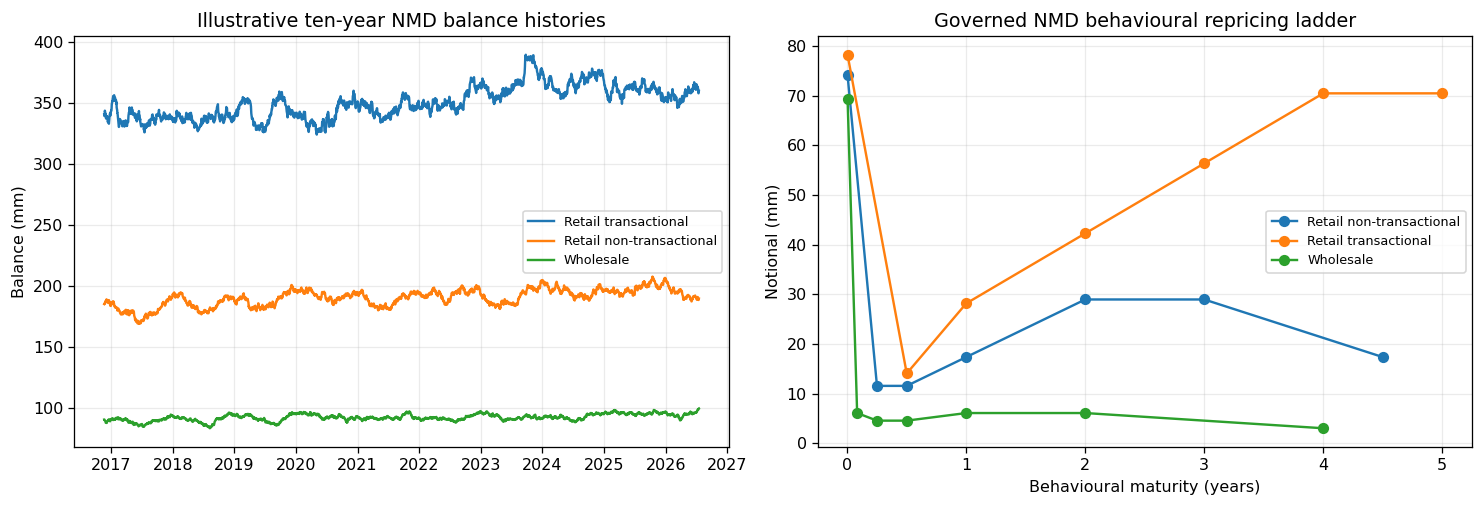

In [7]:
NMD_SEGMENTS = pd.DataFrame([
    {
        "segment": "Retail transactional",
        "target_current_mm": 360.0,
        "core_cap": 0.90,
        "average_maturity_cap_y": 5.0,
        "beta_up": 0.15,
        "beta_down": 0.08,
        "repricing_lag_months": 1,
        "ladder_tenors_y": [0.5, 1.0, 2.0, 3.0, 4.0, 5.0],
        "ladder_weights": [0.05, 0.10, 0.15, 0.20, 0.25, 0.25],
    },
    {
        "segment": "Retail non-transactional",
        "target_current_mm": 190.0,
        "core_cap": 0.70,
        "average_maturity_cap_y": 4.5,
        "beta_up": 0.35,
        "beta_down": 0.22,
        "repricing_lag_months": 1,
        "ladder_tenors_y": [0.25, 0.5, 1.0, 2.0, 3.0, 4.5],
        "ladder_weights": [0.10, 0.10, 0.15, 0.25, 0.25, 0.15],
    },
    {
        "segment": "Wholesale",
        "target_current_mm": 100.0,
        "core_cap": 0.50,
        "average_maturity_cap_y": 4.0,
        "beta_up": 0.65,
        "beta_down": 0.50,
        "repricing_lag_months": 0,
        "ladder_tenors_y": [1/12, 0.25, 0.5, 1.0, 2.0, 4.0],
        "ladder_weights": [0.20, 0.15, 0.15, 0.20, 0.20, 0.10],
    },
])


def simulate_segment_balance(target_current_mm, seed, n_days=2520):
    """Ten-year illustrative history; production calibration requires account data."""
    rng = np.random.default_rng(seed)
    t = np.arange(n_days)
    trend = 0.010 * t
    seasonal = 9.0 * np.sin(2.0 * np.pi * t / 252.0)
    innovations = rng.normal(0.0, 1.0, n_days)
    persistent = np.empty(n_days)
    persistent[0] = 0.0
    for i in range(1, n_days):
        persistent[i] = 0.985 * persistent[i - 1] + innovations[i]
    raw = 430.0 + trend + seasonal + 2.0 * persistent
    raw = np.maximum(raw, 50.0)
    raw *= target_current_mm / raw[-1]
    dates = pd.bdate_range(end=zero_yields.index[-1], periods=n_days)
    return pd.Series(raw, index=dates)


def calibrate_nmd_segments():
    summaries, histories, ladder_rows = [], {}, []
    for i, cfg in NMD_SEGMENTS.iterrows():
        hist = simulate_segment_balance(cfg.target_current_mm, seed=500 + i)
        histories[cfg.segment] = hist
        current = float(hist.iloc[-1])
        stable_volume = float(hist.quantile(0.05))
        # Volume stability and rate stickiness are separated. This is a transparent
        # illustrative rule, not a claim of regulatory approval.
        rate_stickiness = 1.0 - max(cfg.beta_up, cfg.beta_down)
        estimated_core = stable_volume * rate_stickiness
        cap_amount = cfg.core_cap * current
        core = min(estimated_core, cap_amount)
        noncore = current - core
        tenors = np.asarray(cfg.ladder_tenors_y, dtype=float)
        weights = np.asarray(cfg.ladder_weights, dtype=float)
        weights = weights / weights.sum()
        avg_maturity = float(np.sum(tenors * weights))
        if avg_maturity > cfg.average_maturity_cap_y + 1e-12:
            raise ValueError(f"NMD ladder exceeds Basel average-maturity cap for {cfg.segment}")
        summaries.append({
            "segment": cfg.segment,
            "current_mm": current,
            "stable_volume_mm": stable_volume,
            "estimated_core_mm": estimated_core,
            "governance_cap_mm": cap_amount,
            "core_mm": core,
            "noncore_mm": noncore,
            "core_ratio": core / current,
            "weighted_core_maturity_y": avg_maturity,
            "maturity_cap_y": cfg.average_maturity_cap_y,
            "beta_up": cfg.beta_up,
            "beta_down": cfg.beta_down,
            "repricing_lag_months": int(cfg.repricing_lag_months),
        })
        ladder_rows.append({
            "segment": cfg.segment,
            "bucket": "overnight non-core",
            "notional_mm": noncore,
            "behavioural_maturity_y": 1.0 / 365.0,
            "beta_up": cfg.beta_up,
            "beta_down": cfg.beta_down,
            "repricing_lag_months": int(cfg.repricing_lag_months),
            "core_flag": False,
        })
        for tenor, weight in zip(tenors, weights):
            ladder_rows.append({
                "segment": cfg.segment,
                "bucket": f"core {tenor:g}Y",
                "notional_mm": core * weight,
                "behavioural_maturity_y": float(tenor),
                "beta_up": cfg.beta_up,
                "beta_down": cfg.beta_down,
                "repricing_lag_months": int(cfg.repricing_lag_months),
                "core_flag": True,
            })
    return pd.DataFrame(summaries), histories, pd.DataFrame(ladder_rows)


nmd_summary, nmd_histories, nmd_ladder = calibrate_nmd_segments()
CURRENT_NMD_MM = float(nmd_summary.current_mm.sum())
NMD_CORE_MM = float(nmd_summary.core_mm.sum())
NMD_NONCORE_MM = float(nmd_summary.noncore_mm.sum())
NMD_CORE_RATIO = NMD_CORE_MM / CURRENT_NMD_MM
NMD_WEIGHTED_MATURITY = float(
    np.average(nmd_ladder.behavioural_maturity_y, weights=nmd_ladder.notional_mm)
)

display(nmd_summary)
print(f"Total NMD              : {CURRENT_NMD_MM:,.2f} mm")
print(f"Core NMD ratio         : {NMD_CORE_RATIO:.1%}")
print(f"Weighted EVE maturity  : {NMD_WEIGHTED_MATURITY:.2f} years")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for segment, history in nmd_histories.items():
    axes[0].plot(history.index, history, label=segment)
axes[0].set_title("Illustrative ten-year NMD balance histories")
axes[0].set_ylabel("Balance (mm)")
axes[0].legend(fontsize=8)

ladder_plot = nmd_ladder.groupby(["segment", "behavioural_maturity_y"], as_index=False).notional_mm.sum()
for segment, group in ladder_plot.groupby("segment"):
    axes[1].plot(group.behavioural_maturity_y, group.notional_mm, marker="o", label=segment)
axes[1].set_title("Governed NMD behavioural repricing ladder")
axes[1].set_xlabel("Behavioural maturity (years)")
axes[1].set_ylabel("Notional (mm)")
axes[1].legend(fontsize=8)
plt.tight_layout()
NMD_FIGURE = FIGURE_DIR / f"{MODEL_KEY}_05_nmd_profile.png"
plt.savefig(NMD_FIGURE, bbox_inches="tight")
plt.show()

## 6. Banking-book data model and repricing architecture

The book distinguishes contractual maturity, next repricing, behavioural maturity, product optionality, reference index and rate pass-through. Accounting equity reconciles the balance sheet, while Tier 1 capital remains a separate regulatory input. The 19-bucket view is a repricing-gap diagnostic; it is not substituted for full valuation.

,mm
Assets,2000.0
Liabilities,1800.0
Accounting equity,200.0
Tier 1 capital (regulatory input),170.0
Off-balance-sheet IRS notional,150.0


bucket,ON,ON-1M,1M-3M,3M-6M,6M-9M,9M-1Y,1Y-1.5Y,1.5Y-2Y,2Y-3Y,3Y-4Y,4Y-5Y,5Y-6Y,6Y-7Y,7Y-8Y,8Y-9Y,9Y-10Y,10Y-15Y,15Y-20Y,>20Y
signed_notional_mm,-221.708944,-106.122582,-16.180847,469.729701,0.000000,-51.684852,0.000000,-27.363214,-385.330085,106.491449,-237.830626,0.0,220.0,0.0,0.0,0.0,450.0,0.0,0.0
cumulative_gap_mm,-221.708944,-327.831526,-344.012373,125.717328,125.717328,74.032476,74.032476,46.669262,-338.660823,-232.169374,-470.000000,-470.0,-250.0,-250.0,-250.0,-250.0,200.0,200.0,200.0


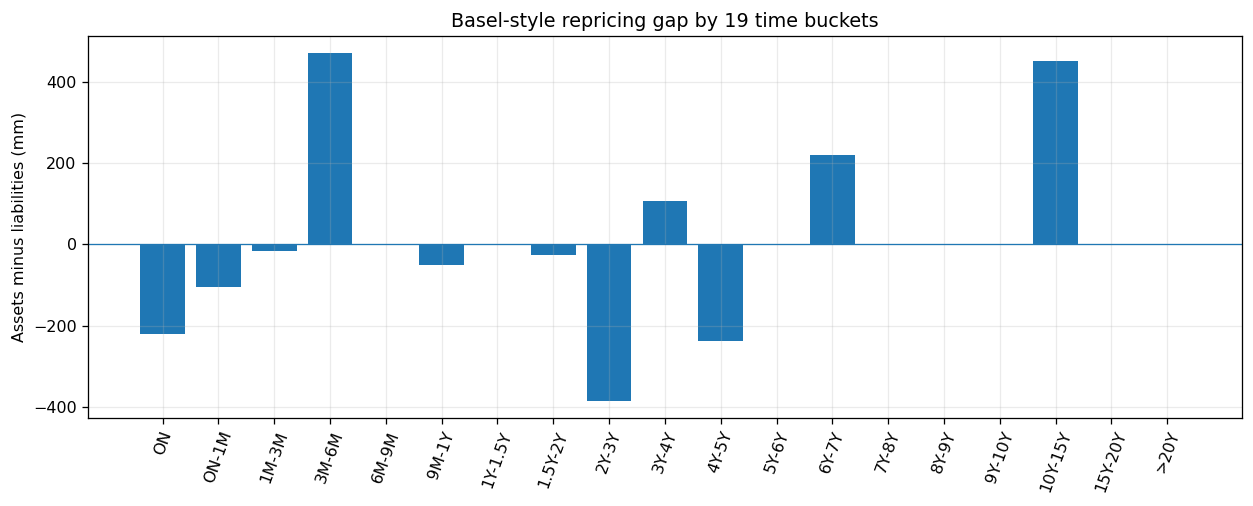

In [8]:
def row(
    instrument_id, side, product, notional_mm, coupon_rate, legal_maturity_y,
    next_repricing_y, rate_type, coupon_frequency=2, amortization="bullet",
    prepayment_rate=0.0, early_redemption_rate=0.0, reference_index="fixed",
    nii_beta_up=1.0, nii_beta_down=1.0, repricing_lag_months=0,
    instrument_type="cash", fixed_leg_sign=0.0,
):
    return {
        "instrument_id": instrument_id,
        "side": side,
        "product": product,
        "currency": CFG.currency,
        "instrument_type": instrument_type,
        "notional_mm": float(notional_mm),
        "coupon_rate": float(coupon_rate),
        "legal_maturity_y": float(legal_maturity_y),
        "next_repricing_y": float(next_repricing_y),
        "rate_type": rate_type,
        "coupon_frequency": int(coupon_frequency),
        "amortization": amortization,
        "prepayment_rate": float(prepayment_rate),
        "early_redemption_rate": float(early_redemption_rate),
        "reference_index": reference_index,
        "nii_beta_up": float(nii_beta_up),
        "nii_beta_down": float(nii_beta_down),
        "repricing_lag_months": int(repricing_lag_months),
        "fixed_leg_sign": float(fixed_leg_sign),
    }


def build_banking_book(core_scale=1.0):
    assets = [
        row("A01", "asset", "Cash and reserves",       100, 0.040, 0.01, 0.01, "floating", 12, reference_index="OIS"),
        row("A02", "asset", "HQLA securities fixed", 250, 0.046, 2.00, 2.00, "fixed", 2),
        row("A03", "asset", "Corporate floating",    300, 0.055, 4.00, 0.25, "floating", 4, reference_index="SOFR"),
        row("A04", "asset", "SME floating",          250, 0.060, 5.00, 0.50, "floating", 2, reference_index="SOFR"),
        row("A05", "asset", "Mortgage fixed",        450, 0.052, 12.0, 12.0, "fixed", 12, "linear", prepayment_rate=0.04),
        row("A06", "asset", "Consumer fixed",        180, 0.061, 4.00, 4.00, "fixed", 12, "linear", prepayment_rate=0.07),
        row("A07", "asset", "Corporate fixed",       220, 0.057, 7.00, 7.00, "fixed", 2),
        row("A08", "asset", "Mortgage floating",     250, 0.054, 8.00, 0.50, "floating", 2, reference_index="SOFR"),
    ]
    liabilities = [
        row("L01", "liability", "Wholesale overnight",     200, 0.038, 0.08, 0.08, "floating", 12, reference_index="SOFR"),
        row("L02", "liability", "Wholesale floating",      250, 0.041, 2.00, 0.25, "floating", 4, reference_index="SOFR"),
        row("L03", "liability", "Term funding fixed",      300, 0.044, 3.00, 3.00, "fixed", 2),
        row("L04", "liability", "Retail term deposits",    200, 0.032, 2.00, 2.00, "fixed", 12, early_redemption_rate=0.03),
        row("L05", "liability", "Secured funding floating",200, 0.039, 1.00, 0.25, "floating", 4, reference_index="SOFR"),
    ]

    # Total NMD remains fixed; core_scale shifts balances between core and non-core.
    nmd_rows = []
    for segment, group in nmd_ladder.groupby("segment"):
        total = float(group.notional_mm.sum())
        core_base = float(group.loc[group.core_flag, "notional_mm"].sum())
        cfg_row = NMD_SEGMENTS.loc[NMD_SEGMENTS.segment == segment].iloc[0]
        core_cap = float(cfg_row.core_cap * total)
        core = min(core_base * core_scale, core_cap, total)
        noncore = total - core
        nmd_rows.append(row(
            f"NMD-{segment[:3]}-NC", "liability", f"NMD {segment} non-core",
            noncore, 0.018, 1/365, 0.0, "behavioural", 12,
            reference_index="administered", nii_beta_up=cfg_row.beta_up,
            nii_beta_down=cfg_row.beta_down, repricing_lag_months=cfg_row.repricing_lag_months,
        ))
        core_group = group[group.core_flag].copy()
        weights = core_group.notional_mm / core_group.notional_mm.sum()
        for j, ((_, ladder_row), weight) in enumerate(zip(core_group.iterrows(), weights), start=1):
            tenor = float(ladder_row.behavioural_maturity_y)
            nmd_rows.append(row(
                f"NMD-{segment[:3]}-{j:02d}", "liability", f"NMD {segment} core",
                core * float(weight), 0.018, tenor, tenor, "behavioural", 12,
                reference_index="administered", nii_beta_up=cfg_row.beta_up,
                nii_beta_down=cfg_row.beta_down, repricing_lag_months=cfg_row.repricing_lag_months,
            ))

    # Pay-fixed / receive-floating swap: an off-balance-sheet hedge.
    derivative = row(
        "D01", "derivative", "Pay-fixed receive-floating IRS", 150, 0.045,
        5.0, 0.25, "swap", 2, reference_index="SOFR", instrument_type="swap",
        fixed_leg_sign=-1.0,
    )
    return pd.DataFrame(assets + liabilities + nmd_rows + [derivative])


banking_book = build_banking_book()
on_balance = banking_book[banking_book.side.isin(["asset", "liability"])]
asset_total = float(on_balance.loc[on_balance.side == "asset", "notional_mm"].sum())
liability_total = float(on_balance.loc[on_balance.side == "liability", "notional_mm"].sum())
accounting_equity = asset_total - liability_total

reconciliation = pd.Series({
    "Assets": asset_total,
    "Liabilities": liability_total,
    "Accounting equity": accounting_equity,
    "Tier 1 capital (regulatory input)": CFG.tier1_capital_mm,
    "Off-balance-sheet IRS notional": float(banking_book.loc[banking_book.instrument_type == "swap", "notional_mm"].sum()),
}, name="mm")
display(reconciliation.to_frame())
assert np.isclose(accounting_equity, CFG.accounting_equity_mm)
assert not np.isclose(CFG.tier1_capital_mm, accounting_equity), "Tier 1 should be distinct from accounting equity in this case study"
assert np.isclose(
    on_balance.loc[on_balance["product"].str.startswith("NMD"), "notional_mm"].sum(),
    CURRENT_NMD_MM,
)

BASEL_BUCKETS = [
    (0.0028, "ON"), (1/12, "ON-1M"), (0.25, "1M-3M"), (0.50, "3M-6M"),
    (0.75, "6M-9M"), (1.00, "9M-1Y"), (1.50, "1Y-1.5Y"), (2.00, "1.5Y-2Y"),
    (3.00, "2Y-3Y"), (4.00, "3Y-4Y"), (5.00, "4Y-5Y"), (6.00, "5Y-6Y"),
    (7.00, "6Y-7Y"), (8.00, "7Y-8Y"), (9.00, "8Y-9Y"), (10.0, "9Y-10Y"),
    (15.0, "10Y-15Y"), (20.0, "15Y-20Y"), (np.inf, ">20Y"),
]

def bucket_name(t):
    t = float(t)
    for upper_bound, name in BASEL_BUCKETS:
        if t <= upper_bound + 1e-12:
            return name
    raise RuntimeError("Unreachable bucket mapping")

repricing_rows = on_balance.copy()
repricing_rows["bucket"] = repricing_rows.next_repricing_y.map(bucket_name)
repricing_rows["signed_notional_mm"] = np.where(
    repricing_rows.side == "asset", repricing_rows.notional_mm, -repricing_rows.notional_mm
)
# Add the two repricing legs of the pay-fixed/receive-floating IRS to the gap view.
swap = banking_book.loc[banking_book["instrument_type"] == "swap"].iloc[0]
derivative_gap = pd.DataFrame([
    {"bucket": bucket_name(swap.next_repricing_y), "signed_notional_mm": swap.notional_mm},
    {"bucket": bucket_name(swap.legal_maturity_y), "signed_notional_mm": -swap.notional_mm},
])
gap_source = pd.concat([repricing_rows[["bucket", "signed_notional_mm"]], derivative_gap], ignore_index=True)
gap_table = (
    gap_source.groupby("bucket", as_index=False).signed_notional_mm.sum()
    .set_index("bucket").reindex([x[1] for x in BASEL_BUCKETS], fill_value=0.0)
)
gap_table["cumulative_gap_mm"] = gap_table.signed_notional_mm.cumsum()
display(gap_table.T)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(gap_table.index, gap_table.signed_notional_mm)
ax.axhline(0.0, linewidth=0.8)
ax.set_title("Basel-style repricing gap by 19 time buckets")
ax.set_ylabel("Assets minus liabilities (mm)")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
GAP_FIGURE = FIGURE_DIR / f"{MODEL_KEY}_06_repricing_gap.png"
plt.savefig(GAP_FIGURE, bbox_inches="tight")
plt.show()

## 7. Cash-flow engine and EVE valuation boundary

This is an **IMS-style full-cash-flow proxy**, not a claim that the standardised framework has been replicated in every detail. Fixed-rate amortising assets include transparent scenario-dependent prepayment scalars; term deposits include early-redemption scalars; floating instruments are valued to next reset; the swap is valued as fixed-leg annuity versus floating leg. Commercial margins remain in contractual coupons and the risk-free fitted curve is used for discounting. A production methodology would require explicit governance over commercial-margin inclusion.

In [9]:
def prepayment_scalar(scenario):
    return {
        "base": 1.00,
        "parallel_up": 0.70,
        "parallel_down": 1.60,
        "short_up": 0.80,
        "short_down": 1.35,
        "steepener": 1.15,
        "flattener": 0.90,
    }[scenario]


def early_redemption_scalar(scenario):
    return {
        "base": 1.00,
        "parallel_up": 1.50,
        "parallel_down": 0.75,
        "short_up": 1.35,
        "short_down": 0.85,
        "steepener": 1.10,
        "flattener": 1.20,
    }[scenario]


def contractual_cashflows(row, scenario="base"):
    horizon = float(row.legal_maturity_y)
    if row.rate_type in {"floating", "behavioural"}:
        horizon = max(float(row.next_repricing_y), 1.0 / 365.0)
    frequency = max(int(row.coupon_frequency), 1)
    step = 1.0 / frequency
    times = np.arange(step, horizon + 1e-12, step)
    if len(times) == 0 or not np.isclose(times[-1], horizon):
        times = np.append(times, horizon)
    accruals = np.diff(np.insert(times, 0, 0.0))
    notional = float(row.notional_mm)
    coupon = float(row.coupon_rate)

    if row.amortization == "linear" and row.rate_type == "fixed":
        scheduled_principal = notional / len(times)
        outstanding = notional
        cfs = []
        cpr = min(float(row.prepayment_rate) * prepayment_scalar(scenario), 0.60)
        for accrual in accruals:
            interest = outstanding * coupon * accrual
            prepay = min(outstanding - scheduled_principal, outstanding * cpr * accrual)
            principal = min(outstanding, scheduled_principal + max(prepay, 0.0))
            cfs.append(interest + principal)
            outstanding -= principal
        if outstanding > 1e-10:
            cfs[-1] += outstanding
        return times, np.asarray(cfs)

    # Fixed-term deposits: the early-redeemed portion stops accruing after withdrawal.
    if row.early_redemption_rate > 0 and row.side == "liability":
        er = min(float(row.early_redemption_rate) * early_redemption_scalar(scenario), 0.50)
        early_t = min(0.5, horizon)
        regular_notional = notional * (1.0 - er)
        early_notional = notional * er
        cashflow_map = {}
        for t, accrual in zip(times, accruals):
            cashflow_map[t] = cashflow_map.get(t, 0.0) + regular_notional * coupon * accrual
        cashflow_map[times[-1]] += regular_notional
        early_interest = early_notional * coupon * early_t
        cashflow_map[early_t] = cashflow_map.get(early_t, 0.0) + early_notional + early_interest
        out_times = np.array(sorted(cashflow_map), dtype=float)
        out_cfs = np.array([cashflow_map[t] for t in out_times], dtype=float)
        return out_times, out_cfs

    cfs = notional * coupon * accruals
    cfs[-1] += notional
    return times, cfs


def discount_factor(times, scenario="base"):
    times = np.asarray(times, dtype=float)
    rates_pct = fitted_zero_rate_pct(times)
    if scenario != "base":
        rates_pct = rates_pct + irrbb_shift_bp(times, scenario) / 100.0
    if CFG.post_shock_floor_pct is not None:
        rates_pct = np.maximum(rates_pct, CFG.post_shock_floor_pct)
    return np.exp(-(rates_pct / 100.0) * times)


def pv_swap(row, scenario="base"):
    T = float(row.legal_maturity_y)
    freq = int(row.coupon_frequency)
    times = np.arange(1.0 / freq, T + 1e-12, 1.0 / freq)
    dfs = discount_factor(times, scenario)
    fixed_annuity = np.sum((1.0 / freq) * dfs)
    pv_fixed = float(row.notional_mm) * float(row.coupon_rate) * fixed_annuity
    pv_float = float(row.notional_mm) * (1.0 - float(discount_factor(np.array([T]), scenario)[0]))
    # fixed_leg_sign=-1 means pay fixed / receive floating.
    return float(row.fixed_leg_sign) * pv_fixed - float(row.fixed_leg_sign) * pv_float


def pv_instrument(row, scenario="base"):
    if row.instrument_type == "swap":
        return pv_swap(row, scenario)
    times, cfs = contractual_cashflows(row, scenario)
    pv = float(np.sum(cfs * discount_factor(times, scenario)))
    return pv if row.side == "asset" else -pv


def value_book(book, scenario="base"):
    details = book.copy()
    details["signed_pv_mm"] = [pv_instrument(r, scenario) for _, r in details.iterrows()]
    return float(details.signed_pv_mm.sum()), details


EVE_BASE_MM, base_details = value_book(banking_book, "base")
print(f"Base EVE (IMS full-cash-flow proxy): {EVE_BASE_MM:,.3f} mm")
product_pv = base_details.groupby(["side", "product"], as_index=False).signed_pv_mm.sum()
display(product_pv)

Base EVE (IMS full-cash-flow proxy): 271.155 mm


,side,product,signed_pv_mm
0,asset,Cash and reserves,99.997743
1,asset,Consumer fixed,185.908115
2,asset,Corporate fixed,236.338452
3,asset,Corporate floating,300.962288
4,asset,HQLA securities fixed,252.305975
5,asset,Mortgage fixed,465.282166
6,asset,Mortgage floating,251.482920
7,asset,SME floating,252.217534
8,derivative,Pay-fixed receive-floating IRS,-1.371999
9,liability,NMD Retail non-transactional core,-110.415485


## 8. Prescribed ΔEVE scenarios, capital test and assumption sensitivity

The six Basel scenarios are applied per currency. The supervisory diagnostic is the maximum adverse ΔEVE divided by Tier 1 capital, not ΔEVE divided by base EVE. Because behavioural assumptions can dominate IRRBB, the engine also reruns the scenario set after scaling the core NMD allocation while total NMD remains fixed.

,shocked_EVE_mm,delta_EVE_mm,adverse_loss_mm,adverse_delta_EVE_to_Tier1_pct,limit_utilisation_pct,outlier_breach
scenario,,,,,,
parallel_up,246.362443,-24.792137,24.792137,14.583610,97.224065,False
steepener,253.587151,-17.567428,17.567428,10.333781,68.891874,False
short_up,267.160403,-3.994176,3.994176,2.349515,15.663435,False
short_down,274.479675,3.325096,0.000000,0.000000,0.000000,False
flattener,284.002235,12.847656,0.000000,0.000000,0.000000,False
parallel_down,292.394326,21.239747,0.000000,0.000000,0.000000,False


Worst scenario                    : parallel_up
Maximum adverse ΔEVE / Tier 1     : 14.58%
15% supervisory outlier threshold : 15.00%


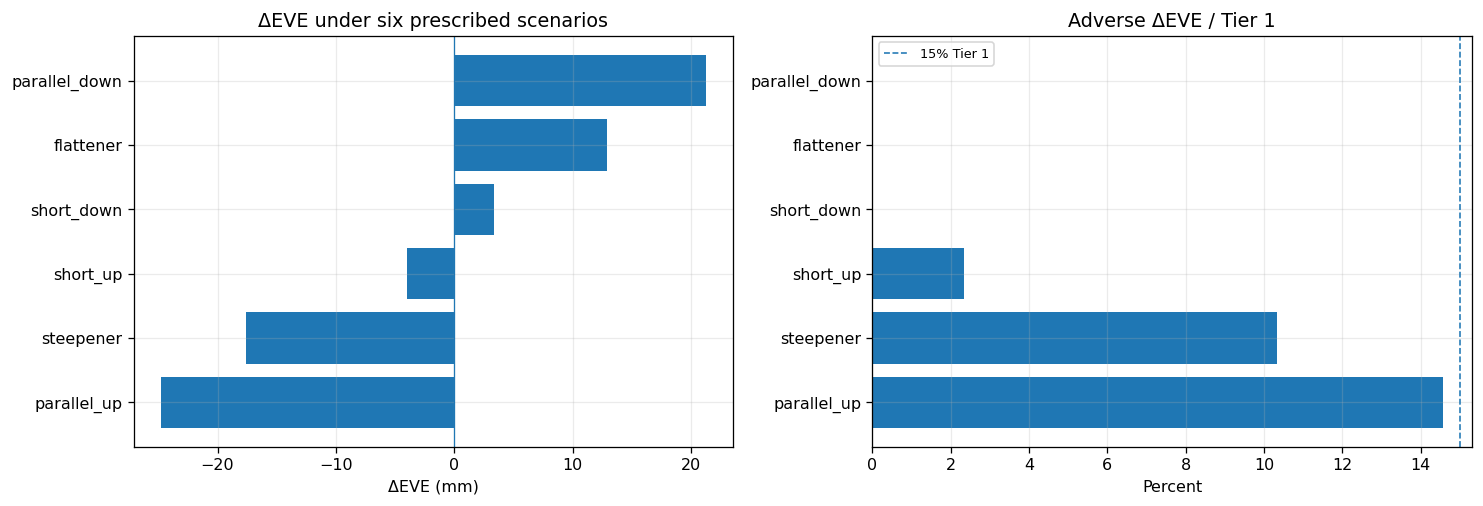

,core_scale,worst_scenario,worst_loss_mm,worst_loss_to_Tier1_pct
0,0.8,parallel_up,28.928026,17.016486
1,1.0,parallel_up,24.792137,14.583610
2,1.2,parallel_up,21.672423,12.748484


In [10]:
def irrbb_shift_bp(times, scenario, currency=CFG.currency):
    times = np.asarray(times, dtype=float)
    cfg = SHOCK_CONFIG_BP[currency]
    short = cfg["short"] * np.exp(-times / CFG.shock_decay_years)
    long = cfg["long"] * (1.0 - np.exp(-times / CFG.shock_decay_years))
    if scenario == "parallel_up":
        return np.full_like(times, cfg["parallel"])
    if scenario == "parallel_down":
        return np.full_like(times, -cfg["parallel"])
    if scenario == "short_up":
        return short
    if scenario == "short_down":
        return -short
    if scenario == "steepener":
        return -0.65 * short + 0.90 * long
    if scenario == "flattener":
        return 0.80 * short - 0.60 * long
    raise ValueError(f"Unknown scenario: {scenario}")

SCENARIOS = ["parallel_up", "parallel_down", "steepener", "flattener", "short_up", "short_down"]
scenario_rows = []
for scenario in SCENARIOS:
    shocked_eve, _ = value_book(banking_book, scenario)
    delta = shocked_eve - EVE_BASE_MM
    adverse = max(-delta, 0.0)
    scenario_rows.append({
        "scenario": scenario,
        "shocked_EVE_mm": shocked_eve,
        "delta_EVE_mm": delta,
        "adverse_loss_mm": adverse,
        "adverse_delta_EVE_to_Tier1_pct": 100.0 * adverse / CFG.tier1_capital_mm,
        "limit_utilisation_pct": 100.0 * adverse / (CFG.outlier_limit * CFG.tier1_capital_mm),
        "outlier_breach": adverse / CFG.tier1_capital_mm >= CFG.outlier_limit,
    })
irrbb_table = pd.DataFrame(scenario_rows).set_index("scenario").sort_values("delta_EVE_mm")
worst_scenario = str(irrbb_table.index[0])
worst_loss_mm = float(irrbb_table.iloc[0].adverse_loss_mm)
worst_ratio = worst_loss_mm / CFG.tier1_capital_mm

display(irrbb_table)
print(f"Worst scenario                    : {worst_scenario}")
print(f"Maximum adverse ΔEVE / Tier 1     : {worst_ratio:.2%}")
print(f"15% supervisory outlier threshold : {CFG.outlier_limit:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_table = irrbb_table.sort_values("delta_EVE_mm")
axes[0].barh(plot_table.index, plot_table.delta_EVE_mm)
axes[0].axvline(0.0, linewidth=0.8)
axes[0].set_title("ΔEVE under six prescribed scenarios")
axes[0].set_xlabel("ΔEVE (mm)")
axes[1].barh(plot_table.index, plot_table.adverse_delta_EVE_to_Tier1_pct)
axes[1].axvline(CFG.outlier_limit * 100.0, linestyle="--", linewidth=1.0, label="15% Tier 1")
axes[1].set_title("Adverse ΔEVE / Tier 1")
axes[1].set_xlabel("Percent")
axes[1].legend(fontsize=8)
plt.tight_layout()
EVE_FIGURE = FIGURE_DIR / f"{MODEL_KEY}_07_eve_scenarios.png"
plt.savefig(EVE_FIGURE, bbox_inches="tight")
plt.show()

# Key behavioural-assumption sensitivity: change core NMD allocation while total NMD is fixed.
sensitivity_rows = []
for scale in [0.80, 1.00, 1.20]:
    b = build_banking_book(core_scale=scale)
    base, _ = value_book(b, "base")
    losses = {}
    for scenario in SCENARIOS:
        shocked, _ = value_book(b, scenario)
        losses[scenario] = max(base - shocked, 0.0)
    worst = max(losses, key=losses.get)
    sensitivity_rows.append({
        "core_scale": scale,
        "worst_scenario": worst,
        "worst_loss_mm": losses[worst],
        "worst_loss_to_Tier1_pct": 100.0 * losses[worst] / CFG.tier1_capital_mm,
    })
nmd_sensitivity = pd.DataFrame(sensitivity_rows)
display(nmd_sensitivity)

## 9. Twelve-month constant-balance-sheet ΔNII

The earnings simulation is monthly rather than a single exposure-period approximation. Positions remain at constant balances; rates change only after their contractual or behavioural repricing point; product-specific asymmetric deposit betas and lags are applied; the swap contributes fixed-versus-floating carry. The two prescribed parallel NII shocks are compared with the unshocked 12-month path.

Base 12-month NII : 49.992 mm
ΔNII parallel up  : +1.885 mm
ΔNII parallel down: -2.482 mm


,parallel_up,parallel_down
product,,
Wholesale floating,-4.166667,4.166667
Wholesale overnight,-4.000000,4.000000
Secured funding floating,-3.333333,3.333333
NMD Wholesale non-core,-0.902032,0.693871
NMD Retail non-transactional non-core,-0.518776,0.326088
NMD Retail transactional non-core,-0.234633,0.125138
NMD Wholesale core,-0.170795,0.131380
NMD Retail non-transactional core,-0.101403,0.063739
NMD Retail transactional core,-0.021134,0.011272


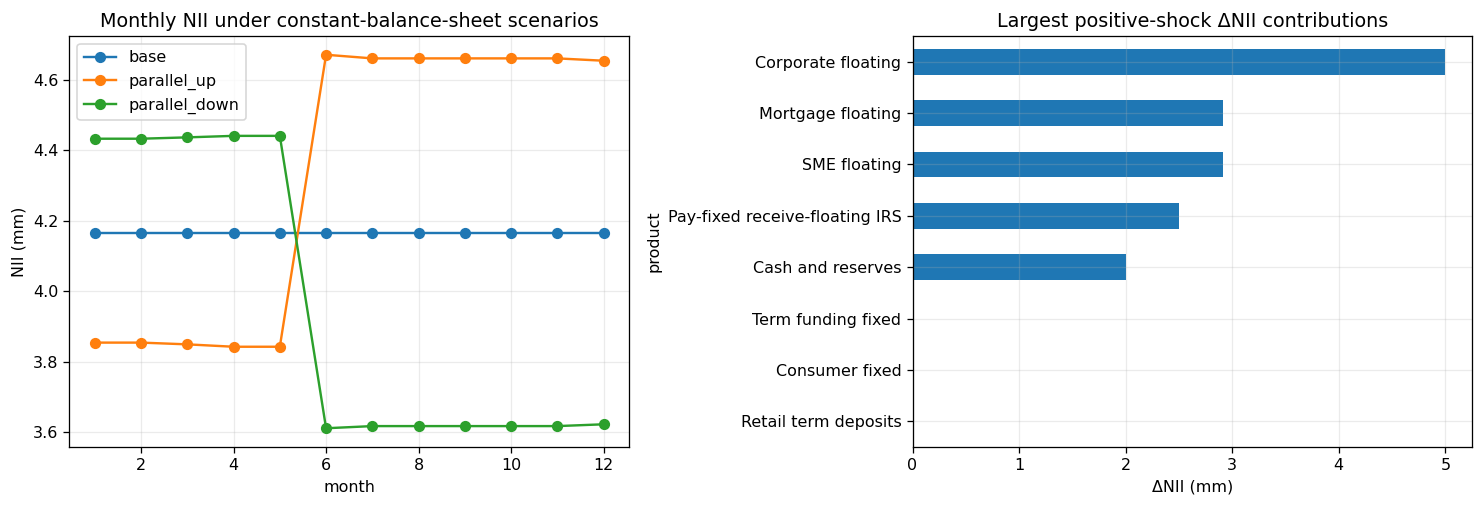

In [11]:
def monthly_nii(book, parallel_shock_bp=0.0):
    """Constant-balance-sheet 12-month NII path with discrete repricing."""
    shock = parallel_shock_bp / 10_000.0
    months = np.arange(1, CFG.nii_horizon_months + 1)
    records = []
    for _, r in book.iterrows():
        if r.instrument_type == "swap":
            fixed_monthly = float(r.notional_mm) * float(r.coupon_rate) / 12.0
            reset_month = max(1, int(np.ceil(float(r.next_repricing_y) * 12)))
            float_base = float(fitted_zero_rate_pct(np.array([max(r.next_repricing_y, 0.25)]))[0]) / 100.0
            for m in months:
                float_rate = float_base + (shock if m >= reset_month else 0.0)
                # pay fixed / receive floating when fixed_leg_sign=-1
                income = float(r.notional_mm) * float_rate / 12.0 - fixed_monthly
                records.append({"month": m, "instrument_id": r.instrument_id, "product": r["product"], "nii_mm": income})
            continue

        base_rate = float(r.coupon_rate)
        reset_month = int(np.ceil(float(r.next_repricing_y) * 12))
        reset_month += int(r.repricing_lag_months)
        beta = float(r.nii_beta_up if parallel_shock_bp >= 0 else r.nii_beta_down)
        sign = 1.0 if r.side == "asset" else -1.0
        for m in months:
            repriced = (r.rate_type in {"floating", "behavioural"} and m >= max(reset_month, 1))
            if r.rate_type == "fixed" and reset_month <= CFG.nii_horizon_months:
                repriced = m >= max(reset_month, 1)
            rate = base_rate + (beta * shock if repriced else 0.0)
            rate = max(rate, 0.0)
            nii = sign * float(r.notional_mm) * rate / 12.0
            records.append({"month": m, "instrument_id": r.instrument_id, "product": r["product"], "nii_mm": nii})
    return pd.DataFrame(records)

base_nii_path = monthly_nii(banking_book, 0.0)
up_nii_path = monthly_nii(banking_book, SHOCK_CONFIG_BP[CFG.currency]["parallel"])
down_nii_path = monthly_nii(banking_book, -SHOCK_CONFIG_BP[CFG.currency]["parallel"])

base_nii = float(base_nii_path.nii_mm.sum())
nii_up = float(up_nii_path.nii_mm.sum() - base_nii)
nii_down = float(down_nii_path.nii_mm.sum() - base_nii)
print(f"Base 12-month NII : {base_nii:,.3f} mm")
print(f"ΔNII parallel up  : {nii_up:+,.3f} mm")
print(f"ΔNII parallel down: {nii_down:+,.3f} mm")

up_attr = up_nii_path.groupby("product").nii_mm.sum() - base_nii_path.groupby("product").nii_mm.sum()
down_attr = down_nii_path.groupby("product").nii_mm.sum() - base_nii_path.groupby("product").nii_mm.sum()
nii_attribution = pd.concat([up_attr.rename("parallel_up"), down_attr.rename("parallel_down")], axis=1).fillna(0.0)
display(nii_attribution.sort_values("parallel_up"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
monthly = pd.DataFrame({
    "base": base_nii_path.groupby("month").nii_mm.sum(),
    "parallel_up": up_nii_path.groupby("month").nii_mm.sum(),
    "parallel_down": down_nii_path.groupby("month").nii_mm.sum(),
})
monthly.plot(ax=axes[0], marker="o")
axes[0].set_title("Monthly NII under constant-balance-sheet scenarios")
axes[0].set_ylabel("NII (mm)")
nii_attribution.parallel_up.sort_values().tail(8).plot(kind="barh", ax=axes[1])
axes[1].set_title("Largest positive-shock ΔNII contributions")
axes[1].set_xlabel("ΔNII (mm)")
plt.tight_layout()
NII_FIGURE = FIGURE_DIR / f"{MODEL_KEY}_08_nii.png"
plt.savefig(NII_FIGURE, bbox_inches="tight")
plt.show()

## 10. Validation, artifact contract and reproducibility

Assertions cover units, curve conditioning, NMD caps, reconciliation, shock signs and aggregation. Each model writes the same result contract (`metrics.json`, scenario tables, diagnostics and figures), allowing the markdown-only case-study notebook to compare the two engines without hidden manual calculations.

In [12]:
# Integration, unit and governance checks.
assert zero_yields.index.is_monotonic_increasing
assert zero_yields.notna().all().all()
assert np.isfinite(fitted_values).all()
assert design_condition < 1_000.0, "Loading matrix exceeds hard governance limit"
assert max_loading_corr < 0.995, "Loading correlation exceeds hard governance limit"
assert np.isclose(asset_total, liability_total + CFG.accounting_equity_mm)
assert np.isclose(CURRENT_NMD_MM, 650.0)
assert (nmd_summary.weighted_core_maturity_y <= nmd_summary.maturity_cap_y + 1e-12).all()
assert np.isfinite(irrbb_table.select_dtypes(include=[np.number]).values).all()
assert np.isclose(irrbb_shift_bp(np.array([1.0, 10.0]), "parallel_up"), SHOCK_CONFIG_BP[CFG.currency]["parallel"]).all()
assert worst_ratio >= 0.0
assert np.isfinite([base_nii, nii_up, nii_down]).all()


# Shared run lineage: both model notebooks must produce the same fingerprint.
dataset_payload = zero_yields.to_csv(index=True, float_format="%.12g").encode("utf-8")
dataset_fingerprint = hashlib.sha256(dataset_payload).hexdigest()
report_group_payload = json.dumps({
    "dataset_fingerprint": dataset_fingerprint,
    "currency": CFG.currency,
    "tier1_capital_mm": CFG.tier1_capital_mm,
    "accounting_equity_mm": CFG.accounting_equity_mm,
    "outlier_limit": CFG.outlier_limit,
    "shock_config_bp": SHOCK_CONFIG_BP[CFG.currency],
    "nmd_core_ratio": float(NMD_CORE_RATIO),
}, sort_keys=True).encode("utf-8")
report_group_id = hashlib.sha256(report_group_payload).hexdigest()
generated_at_utc = datetime.now(timezone.utc).isoformat()

metrics = {
    "artifact_schema_version": "2.0",
    "model_key": MODEL_KEY,
    "model_name": MODEL_NAME,
    "data_source": DATA_SOURCE,
    "dataset_fingerprint": dataset_fingerprint,
    "report_group_id": report_group_id,
    "generated_at_utc": generated_at_utc,
    "reference_date": str(zero_yields.index.max().date()),
    "observations": int(n_obs),
    "train_observations": int(len(train_panel)),
    "validation_observations": int(len(validation_panel)),
    "test_observations": int(len(test_panel)),
    "lambda1_years": float(lambda1_hat),
    "lambda2_years": float(lambda2_hat) if lambda2_hat is not None else None,
    "design_condition_number": float(design_condition),
    "maximum_loading_correlation": float(max_loading_corr),
    "vif": {k: float(v) for k, v in vif.items()},
    "train_mean_rmse_bp": float(train_rmse.mean()),
    "validation_mean_rmse_bp": float(validation_rmse.mean()),
    "test_mean_rmse_bp": float(test_rmse.mean()),
    "test_p95_rmse_bp": float(np.quantile(test_rmse, 0.95)),
    "test_max_point_error_bp": float(np.max(np.abs(test_errors_bp))),
    "pca_explained_variance": [float(x) for x in pca.explained_variance_ratio_],
    "level_factor_abs_correlation": float(abs(factor_corr.loc["PC1", "beta0"])),
    "matched_factor_abs_correlation_mean": float(np.mean(matched_factor_corr)),
    "factor_correlation_matrix": factor_corr.astype(float).to_dict(),
    "curve_shape_checks": curve_checks,
    "nmd_core_ratio": float(NMD_CORE_RATIO),
    "nmd_weighted_maturity_years": float(NMD_WEIGHTED_MATURITY),
    "accounting_equity_mm": float(accounting_equity),
    "tier1_capital_mm": float(CFG.tier1_capital_mm),
    "base_eve_mm": float(EVE_BASE_MM),
    "worst_eve_scenario": worst_scenario,
    "maximum_adverse_delta_eve_mm": float(worst_loss_mm),
    "maximum_adverse_delta_eve_to_tier1_pct": float(100.0 * worst_ratio),
    "outlier_breach": bool(worst_ratio >= CFG.outlier_limit),
    "base_nii_mm": float(base_nii),
    "delta_nii_parallel_up_mm": float(nii_up),
    "delta_nii_parallel_down_mm": float(nii_down),
}

model_artifact_dir = ARTIFACT_DIR / MODEL_KEY
model_artifact_dir.mkdir(exist_ok=True)
with open(model_artifact_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)
params.to_csv(model_artifact_dir / "curve_parameters.csv")
fit_diagnostics.to_csv(model_artifact_dir / "fit_diagnostics.csv")
factor_corr.to_csv(model_artifact_dir / "factor_correlations.csv")
nmd_summary.to_csv(model_artifact_dir / "nmd_summary.csv", index=False)
nmd_ladder.to_csv(model_artifact_dir / "nmd_ladder.csv", index=False)
gap_table.to_csv(model_artifact_dir / "repricing_gap.csv")
irrbb_table.to_csv(model_artifact_dir / "eve_scenarios.csv")
nii_attribution.to_csv(model_artifact_dir / "nii_attribution.csv")
nmd_sensitivity.to_csv(model_artifact_dir / "nmd_sensitivity.csv", index=False)


def _sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

required_table_files = [
    "metrics.json", "curve_parameters.csv", "fit_diagnostics.csv",
    "factor_correlations.csv", "nmd_summary.csv", "nmd_ladder.csv",
    "repricing_gap.csv", "eve_scenarios.csv", "nii_attribution.csv",
    "nmd_sensitivity.csv",
]
required_figure_files = [
    f"{MODEL_KEY}_01_curve_fit.png",
    f"{MODEL_KEY}_02_factor_alignment.png",
    f"{MODEL_KEY}_03_identification.png",
    f"{MODEL_KEY}_05_nmd_profile.png",
    f"{MODEL_KEY}_06_repricing_gap.png",
    f"{MODEL_KEY}_07_eve_scenarios.png",
    f"{MODEL_KEY}_08_nii.png",
]
for filename in required_table_files:
    if not (model_artifact_dir / filename).exists():
        raise FileNotFoundError(model_artifact_dir / filename)
for filename in required_figure_files:
    if not (FIGURE_DIR / filename).exists():
        raise FileNotFoundError(FIGURE_DIR / filename)

run_manifest = {
    "artifact_schema_version": "2.0",
    "model_key": MODEL_KEY,
    "model_name": MODEL_NAME,
    "dataset_fingerprint": dataset_fingerprint,
    "report_group_id": report_group_id,
    "data_source": DATA_SOURCE,
    "reference_date": str(zero_yields.index.max().date()),
    "generated_at_utc": generated_at_utc,
    "tables": {name: _sha256_file(model_artifact_dir / name) for name in required_table_files},
    "figures": {name: _sha256_file(FIGURE_DIR / name) for name in required_figure_files},
}
with open(model_artifact_dir / "run_manifest.json", "w", encoding="utf-8") as handle:
    json.dump(run_manifest, handle, indent=2)

print("All validation checks passed.")
print(f"Artifacts written to: {model_artifact_dir}")
display(pd.Series(metrics).to_frame("value"))

All validation checks passed.
Artifacts written to: /Users/ugural/Quantitative_Research/irrbb/upcoming/irrbb_dynamic_report_project/artifacts/ns3


,value
artifact_schema_version,2.0
model_key,ns3
model_name,Three-factor Nelson–Siegel
data_source,Federal Reserve GSW SVENY zero-coupon curve (l...
dataset_fingerprint,38cad0a67e149b1c73ca0226c08ab8953a9c22eb0792e7...
report_group_id,9ab3a69f7694905b883236669da47832841425b14610ff...
generated_at_utc,2026-07-24T15:55:53.404235+00:00
reference_date,2026-07-17
observations,1000
train_observations,600


## 11. Scope limitations and production migration

**Implemented well enough for a portfolio case:** data provenance, temporal validation, model identification, behavioural segmentation, EVE/NII integration, prescribed shocks, capital normalization, key-assumption sensitivity, artifact versioning and reproducible controls.

**Still illustrative:** the balance sheet and deposit histories are synthetic; no account-level NMD, prepayment or early-redemption estimation is performed; basis risk and CSRBB are not quantified; multicurrency aggregation and FX translation are absent; automatic options are not priced with dedicated option models; legal-entity consolidation, hedge accounting, FTP, market-data lineage, access control and independent model validation remain outside the notebook.

In production, the approved discount/projection curve service should be separate from the structural factor model. A curve representation that is useful for attribution is not automatically the correct pricing curve, and a low-RMSE pricing representation is not automatically an identified risk-factor model.